# YOLO v8 Implementation

## Install packages

In [ ]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.0 MB/s eta 0:00:00


## Using ```yolov8n.pt``` (Nano) model for object detection

### display the image we'll be running YOLO on

In [ ]:
from ultralytics import YOLO
import os
from IPython.display import Image, display

# 1. Load the pre-trained YOLOv8 Nano model
model = YOLO('yolov8n.pt') # The 'n' stands for Nano, which is the fastest and most lightweight version

# 2. Define our image source
# Ultralytics is smart enough to download and process an image directly from a URL
image_source = 'https://ultralytics.com/images/bus.jpg'

# Let's display 'bus.jpg' to see the image we are about to pass to our YOLO algorithm
print("Here is our input image:")
display(Image(url=image_source))

Here is our input image:


### Get output

In [ ]:
# 3. Run inference (prediction)
print("Running YOLOv8 inference...")

# 'save=True' tells YOLO to save a copy of the image with bounding boxes drawn on it
# 'conf=0.25' tells the model to ignore any predictions it is less than 25% confident about
results = model.predict(source=image_source, save=True, conf=0.25)
results

Running YOLOv8 inference...

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 192.3ms
Speed: 11.4ms preprocess, 192.3ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-3


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

### Understanding the Results Object

After exploring `results`, we can understand that it is a list of prediction objects, where each prediction object corresponds to one input image.

Since YOLOv8 was trained on the **COCO dataset**, the model knows **80 object classes** (such as person, car, bus, dog, etc.). However, `results` does **not** contain information for all 80 classes. It only stores predictions for the objects that were actually detected in the input image.

So, let's explore what was predicted for our target image.

`results[0].boxes` contains the final filtered detections generated after post-processing. Each detected object includes:

- Bounding box coordinates  
- Confidence score  
- Class ID (mapped to a class label)

In [ ]:
# Since we only passed one image to the model, we look at the first result: results[0]
boxes = results[0].boxes

# Let's look at the raw PyTorch tensors the model generated for all detected objects!

print("1. CLASS IDs (Which of the 80 COCO objects did it find?):")
print(boxes.cls)
print("*" * 60)

print("2. CONFIDENCE SCORES (How sure is the model, from 0.0 to 1.0?):")
print(boxes.conf)
print("*" * 60)

print("3. BOUNDING BOX COORDINATES (Center X, Center Y, Width, Height):")
print(boxes.xywh)

1. CLASS IDs (Which of the 80 COCO objects did it find?):
tensor([ 5.,  0.,  0.,  0.,  0., 11.])
************************************************************
2. CONFIDENCE SCORES (How sure is the model, from 0.0 to 1.0?):
tensor([0.8734, 0.8657, 0.8528, 0.8252, 0.2611, 0.2551])
************************************************************
3. BOUNDING BOX COORDINATES (Center X, Center Y, Width, Height):
tensor([[413.9370, 494.0588, 782.1314, 525.5630],
        [146.9480, 650.6274, 196.7951, 504.1505],
        [739.5966, 634.6108, 140.2473, 484.8493],
        [283.2440, 631.6676, 123.4533, 451.7380],
        [ 31.5035, 711.9840,  63.0070, 322.9179],
        [ 16.3078, 289.6668,  32.4992,  70.4147]])


### Loop over each object in the input image & explore the predictions

In [ ]:
print(f"YOLO found {len(boxes)} objects in the image.\n")

# Let's loop through every single detected object and make the data readable
for box in boxes:

    # 1. Class ID & Name (What is it?)
    # .item() pulls the single number out of the complex PyTorch tensor
    class_id = int(box.cls[0].item())
    class_name = results[0].names[class_id] # Look up the actual word using the ID

    # 2. Confidence Score (How sure is the model?)
    conf = box.conf[0].item()

    # 3. Bounding Box Coordinates: Center X, Center Y, Width, Height
    # .tolist() converts the PyTorch array into a standard Python list
    coords = box.xywh[0].tolist()

    # Format the coordinates to 2 decimal places for cleaner printing
    formatted_coords = [round(num, 2) for num in coords]

    # Print the decoded results!
    print(f"Object: {class_name.upper()}")
    print(f"Confidence: {conf * 100:.1f}%")
    print(f"Coordinates (x, y, w, h): {formatted_coords}")
    print("-" * 30)

YOLO found 6 objects in the image.

Object: BUS
Confidence: 87.3%
Coordinates (x, y, w, h): [413.94, 494.06, 782.13, 525.56]
------------------------------
Object: PERSON
Confidence: 86.6%
Coordinates (x, y, w, h): [146.95, 650.63, 196.8, 504.15]
------------------------------
Object: PERSON
Confidence: 85.3%
Coordinates (x, y, w, h): [739.6, 634.61, 140.25, 484.85]
------------------------------
Object: PERSON
Confidence: 82.5%
Coordinates (x, y, w, h): [283.24, 631.67, 123.45, 451.74]
------------------------------
Object: PERSON
Confidence: 26.1%
Coordinates (x, y, w, h): [31.5, 711.98, 63.01, 322.92]
------------------------------
Object: STOP SIGN
Confidence: 25.5%
Coordinates (x, y, w, h): [16.31, 289.67, 32.5, 70.41]
------------------------------



Success! Annotated image saved to: /content/runs/detect/predict-3
Displaying the final result below:



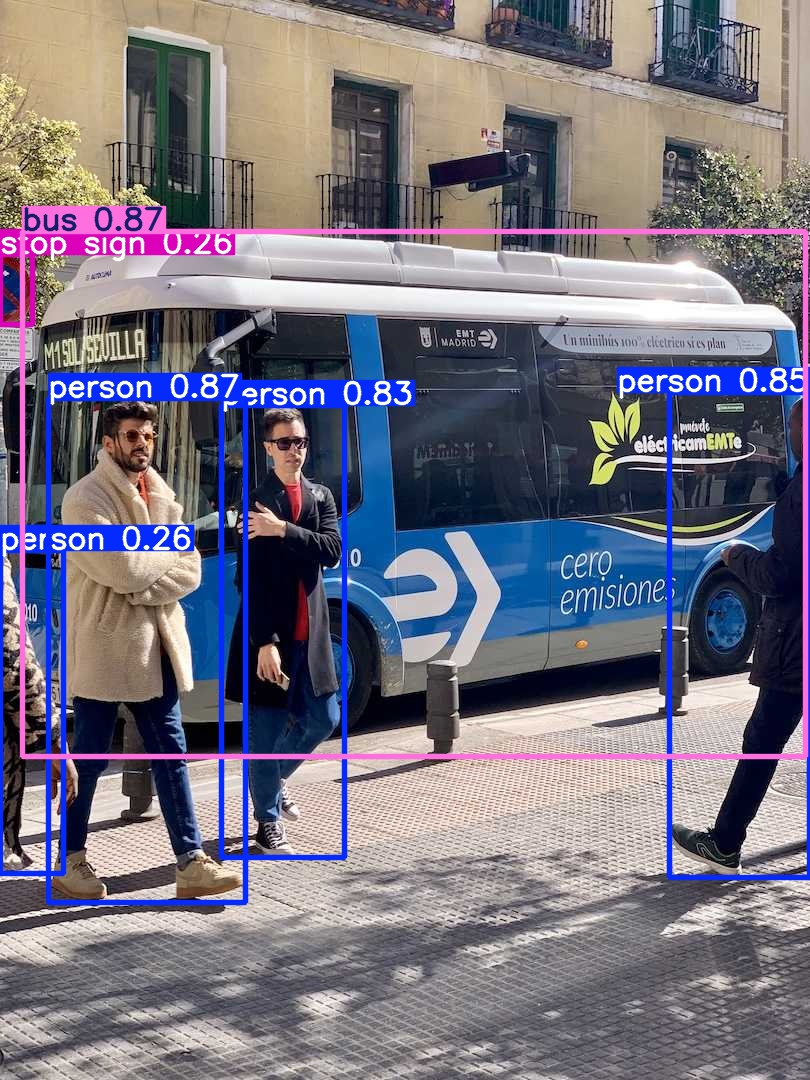

In [ ]:
# 4. Locate and display the saved annotated image
# YOLO automatically creates a folder structure like 'runs/detect/predict' for our outputs
output_dir = results[0].save_dir

# Grab just the filename ('bus.jpg') from our original long URL
image_filename = os.path.basename(image_source)

print(f"\nSuccess! Annotated image saved to: {output_dir}")
print("Displaying the final result below:\n")

# Display the image right here in our notebook
display(Image(filename=os.path.join(output_dir, image_filename), width=600))